# RANDOM FOREST - Algoritmo de clasificación

***Random Forest*** es un algoritmo de Aprendizaje Supervisado que se utiliza tanto para clasificación como para regresión, aunque se suele emplear mayoritariamente en problemas de clasificación.   

Como sabemos, un bosque está formado por gran cantidad de árboles y, a mayor cantidad de estos, más 'robusto' es. De forma similar, este algoritmo se crea generando un 'conjunto' de arboles de decisión sobre los datos de ejemplo y se toma las decisiones de cada uno de estos árboles para, finalmente, seleccionar la mejor solución a través de la 'recolección y conteo de votos' volcados por los distintos árboles del conjunto o bosque.   

Este método de ensemble es mucho mejor que el uso de un único árbol de decisión ya que, entre otras cosas, reduce la posibilidad de "overfitting" gracias a usar la "media" de los resultados.

## Funcionamiento del algoritmo Random Forest    

El ciclo de funcionamiento del Random Forest es el siguiente:    

1. Se inicia con la selección de ejemplos aleatorios del dataset analizado.
2. A continuación, el algoritmo construirá un árbol de decisión para cada ejemplo. Entonces se generará la predicción por cada árbol de decisión.
3. En este paso, se produce la votación para cada resultado de predicción.
4. Finalmente, se selecciona la predicción más votada y esta se transforma en el resultado final de predicción.

## Implementación en Python.    

Primero, importamos las librerías necesarias:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Ahora, cargamos el dataset

In [2]:
path = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

Lo siguiente es cambiar los nombres de las columnas y adecuarlos a nuestras necesidades:

In [3]:
headernames = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

Se lee el dataset, para cargarlo en un dataframe de pandas

In [4]:
dataset = pd.read_csv(path, names=headernames)
dataset.head()

,sepal-length,sepal-width,petal-length,petal-width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Realizamos el preprocesado del dataframe

In [5]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 4].values

Dividimos para obtener los conjuntos de `train` y `test`:

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

Ejecutamos el entrenamiento con `RandomForestClassifier`de `sklearn`:

In [7]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=50, random_state=0)
classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

Realizamos la predicción:

In [8]:
y_pred = classifier.predict(X_test)

Mostramos los resultados:

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
result = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(result)   
result1 = classification_report(y_test, y_pred)
print("Classification Report:")
print(result1)
result2 = accuracy_score(y_test, y_pred)
print("Accuracy:", result2)

Confusion Matrix:
[[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        16
Iris-versicolor       1.00      0.94      0.97        18
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.98        45
      macro avg       0.97      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45

Accuracy: 0.9777777777777777


## Pros y Contras de Random Forest   

### Pros

- Evita el problema del `overfitting` usando la media o combinando los resultados de los distintos árboles de decisión. 
- Random Forest funciona muy bien con datasets de gran tamaño; mucho mejor que los árboles de decisión individuales.
- Random Forest tiene menor varianza que los árboles de decisión individuales.
- Random Forest son más flexibles y son más precisos ("accuracy").
- El escalado de información no es necesario para este tipo de algoritmo. La precisión se mantiene aunque no se escalen los datos.
- Este algoritmo mantiene un buen nivel de precisión aunque exista gran cantidad de datos ausentes.

### Contras

- La complejidad es una de sus debilidades.
- La construcción del bosque es muy costosa y consume más tiempo que los árboles de decisión individuales.
- Requiere más potencia de cómputo.
- El proceso de predicción consume más tiempo que otros algoritmos.

## Hiperparámetros de Random Forest    

En el momento de ajustar el modelo, debemos tener en cuenta los siguientes hiperparámetros. Estos nos ayudarán a que el bosque obtenga mejores resultados para cada problema:

- **n_estimators**: será la cantidad de árboles que se generarán.
- **max_features**: la manera de seleccionar la cantidad máxima de *features* para cada árbol.
- **min_sample_leaf**: número mínimo de elementos en las hojas para permitir un nuevo split (división) del nodo.
- **oob_score**: es un método que emula el **cross-validation** en árboles y permite mejorar la precisión y evitar overfitting.
- **boostrap**: para utilizar diversos tamaños de muestras para entrenar. Si se pone en falso, utilizará siempre el dataset completo.
- **n_jobs**: si tienes se dispone de múltiples cores en tu CPU, se puede indicar cuantos puede usar el modelo al entrenar para acelerar el entrenamiento.

## Uso de Random Forest como regresor.   
 
El dataset `Boston` contiene precios de viviendas de la ciudad de Boston, así como información socio-económica del barrio en el que se encuentran. Se pretende ajustar un modelo de regresión que permita predecir el precio medio de una vivienda (MEDV) en función de las variables disponibles.   

Vamos a utilizar `RandomForestRegressor` para hacer la predicción del coste de las viviendas.

1.- Carga de librerías

In [10]:
!pip install optuna

In [11]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 8

# Preprocesado y modelado
# ==============================================================================
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
from joblib import Parallel, delayed, cpu_count
import optuna

# Configuración warnings
# ==============================================================================
import warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"Versión de scikit-learn: {sklearn.__version__}")


Versión de scikit-learn: 1.8.0


/home/jordi/Documentos/Ribera/Curso_25_26/CEDAPY/REPOS/CEDAPY_25_26/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Datos
El dataset Boston tiene las siguientes características:

- Número de instancias: 506
- Número de atributos: 13 predictivos numéricos/categoriales.

Información de los atributos (por orden):

- CRIM: tasa de delincuencia per cápita por ciudad.
- ZN: proporción de suelo residencial dividido para segmentos de más de 25.000 pies cuadrados.
- INDUS: proporción de superficie comerciales no minoristas por ciudad.
- CHAS: variable binaria sobre el río Charles (= 1 si la zona linda con el río; 0 en caso contrario).
- NOX: concentración de óxidos nítricos (partes por 10 millones).
- RM: número medio de habitaciones por vivienda.
- EDAD: proporción de viviendas ocupadas construidas antes de 1940.
- DIS: distancia ponderada a cinco centros de empleo en la ciudad de Boston.
- RAD: índice de accesibilidad a las autopistas radiales.
- TAX: impuesto sobre bienes inmuebles de valor íntegro por cada 10.000$.
- PTRATIO: ratio alumnos-profesor por ciudad.
- LSTAT: % de la población considerado de clase baja.
- MEDV: valor medio de las viviendas ocupadas por sus propietarios en miles de $.   

Valores ausentes: Ninguno

In [12]:
# Descarga de datos
# ==============================================================================
url = (
    'https://raw.githubusercontent.com/JoaquinAmatRodrigo/Estadistica-machine-learning-python/'
    'master/data/Boston.csv'
)
datos = pd.read_csv(url, sep=',')
display(datos.head(3))
display(datos.info())


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


None

### Ajuste del modelo   

Se ajusta un modelo empleando como variable respuesta **MEDV** y como predictores todas las otras variables disponibles.

La clase `RandomForestRegressor` del módulo `sklearn.ensemble` permite entrenar modelos random forest para problemas de regresión. Los parámetros e hiperparámetros empleados por defecto son:

- n_estimators=100
- criterion='squared_error'
- max_depth=None
- min_samples_split=2
- min_samples_leaf=1
- min_weight_fraction_leaf=0.0
- max_features=1.0
- max_leaf_nodes=None
- min_impurity_decrease=0.0
- bootstrap=True
- oob_score=False
- n_jobs=None
- random_state=None
- verbose=0
- warm_start=False
- ccp_alpha=0.0
- max_samples=None   


De entre todos ellos, destacan aquellos que detienen el crecimiento de los árboles, los que controlan el número de árboles y predictores incluidos, y los que gestionan la paralelización:

- *n_estimators*: número de árboles incluidos en el modelo.
- *max_depth*: profundidad máxima que pueden alcanzar los árboles.
- *min_samples_split*: número mínimo de observaciones que debe de tener un nodo para que pueda dividirse. Si es un valor decimal se interpreta como fracción del total de observaciones de entrenamiento ceil(min_samples_split * n_samples).
- *min_samples_leaf*: número mínimo de observaciones que debe de tener cada uno de los nodos hijos para que se produzca la división. Si es un valor decimal se interpreta como fracción del total de observaciones de entrenamiento ceil(min_samples_split * n_samples).
- *max_leaf_nodes*: número máximo de nodos terminales que pueden tener los árboles.
- *max_features*: número de predictores considerados a en cada división. Puede ser: 
        - Un valor entero
        - Una fracción del total de predictores..
        - “sqrt”, raiz cuadrada del número total de predictores.
        - “log2”, log2 del número total de predictores.
        - None, utiliza todos los predictores.
- *oob_score*: Si se calcula o no el out-of-bag R^2. Por defecto es False ya que aumenta el tiempo de entrenamiento.
- *n_jobs*: número de cores empleados para el entrenamiento. En random forest los árboles se ajustan de forma independiente, por lo la paralelización reduce notablemente el tiempo de entrenamiento. Con -1 se utilizan todos los cores disponibles.
- *random_state*: semilla para que los resultados sean reproducibles. Tiene que ser un valor entero.     


Como en todo estudio predictivo, no solo es importante ajustar el modelo, sino también cuantificar su capacidad para predecir nuevas observaciones. Para poder hacer esta evaluación, se dividen los datos en dos grupos, uno de entrenamiento y otro de test.

In [13]:
# División de los datos en entrenamiento y test
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
                                        datos.drop(columns="MEDV"),
                                        datos['MEDV'],
                                        test_size = 0.25,
                                        random_state = 123
                                    )

print(f"Tamaño conjunto entrenamiento: {X_train.shape[0]}")
print(f"Tamaño conjunto test: {X_test.shape[0]}")

# Creación del modelo
# ==============================================================================
modelo = RandomForestRegressor(
            n_estimators = 10,
            criterion    = 'squared_error',
            max_depth    = None,
            max_features = 1,
            oob_score    = False,
            n_jobs       = -1,
            random_state = 123
         )

# Entrenamiento del modelo
# ==============================================================================
modelo.fit(X_train, y_train)


Tamaño conjunto entrenamiento: 379
Tamaño conjunto test: 127


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

### Predicción y evaluación del modelo   

Una vez entrenado el modelo, se evalúa la capacidad predictiva empleando el conjunto de test.

In [14]:
# Error de test del modelo inicial
# ==============================================================================
predicciones = modelo.predict(X=X_test)
rmse = root_mean_squared_error(y_true=y_test, y_pred=predicciones)
print(f"El error (RMSE) de test es: {rmse}")


El error (RMSE) de test es: 4.17800427058654


In [16]:
# Cálculo del MSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_true=y_test, y_pred=predicciones)
print(f"El error (MSE) de test es: {mse}")

El error (MSE) de test es: 17.455719685039366


In [15]:
# Cálculo del MAE
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_true=y_test, y_pred=predicciones)
print(f"El error (MAE) de test es: {mae}")

El error (MAE) de test es: 2.8122834645669292


In [17]:
# Cálculo de R²
from sklearn.metrics import r2_score
r2 = r2_score(y_true=y_test, y_pred=predicciones)
print(f"El R² de test es: {r2}")    

El R² de test es: 0.7788798483287804


Análisis de Métricas de Regresión
1. **Error Cuadrático Medio (MSE)** Valor: 17.46. El MSE penaliza con fuerza los errores grandes debido a que eleva las diferencias al cuadrado. Un valor de 17.46 indica que hay cierta dispersión, pero por sí solo es difícil de interpretar porque las unidades están al cuadrado (serían "dólares al cuadrado"). Es útil principalmente para comparar este modelo con otros: si se prueba con otro algoritmo y el MSE baja de 17, estaría bien enfocado.
2. **Error Absoluto Medio (MAE)** Valor: 2.81. Esta es la métrica más "humana". Nos dice que, en promedio, las predicciones del modelo se desvían 2,810 dólares del precio real (asumiendo que los precios están en miles).Interpretación: Es un error bastante decente para el dataset de Boston, indicando que el modelo es relativamente robusto y no está fallando por márgenes salvajes de forma sistemática.
3. **Raíz del Error Cuadrático Medio (RMSE)** Valor: 4.18. Al ser la raíz del MSE, vuelve a la unidad original (miles de dólares).Lo que nos revela: Como el RMSE (4.18) es significativamente mayor que el MAE (2.81), esto nos indica que existen algunos "outliers" o valores atípicos en el set de test donde el modelo se equivoca mucho más que la media. El RMSE castiga esos errores grandes que el MAE suaviza.
4. **Coeficiente de Determinación ($R^2$)** Valor: 0.778. Esta es, quizás, la métrica que mejor resume el éxito del modelo en este contexto. *Interpretación*: El modelo es capaz de explicar aproximadamente el 77.9% de la variabilidad de los precios de las viviendas en Boston.*Veredicto*: Para un modelo base, un $R^2$ cercano al 0.8 es un resultado sólido. Indica que las variables predictoras (crimen, número de habitaciones, etc.) tienen una relación lineal fuerte con el precio, aunque todavía queda un 22% de "incertidumbre" o ruido que el modelo no logra capturar.      

#### Conclusión   
El modelo es bastante competente. No es perfecto, pero un $R^2$ de 0.78 sugiere que es útil para aplicaciones prácticas. El "punto débil" que sugieren los datos es la presencia de errores puntuales grandes (la brecha entre MAE y RMSE).

## Optimización de hiperparámetros  

El modelo inicial se ha entrenado utilizando 10 árboles (*n_estimators=10*) y manteniendo el resto de hiperparámetros con su valor por defecto. Al ser hiperparámetros, no se puede saber de antemano cuál es el valor más adecuado, la forma de identificarlos es mediante el uso de estrategias de validación, por ejemplo validación cruzada.

Los modelos Random Forest tienen la ventaja de disponer del *Out-of-Bag error*, lo que permite obtener una estimación del error de test sin recurrir a la validación cruzada, que es computacionalmente costosa.

### Número de árboles
En Random Forest, el número de árboles no es un hiperparámetro crítico en cuanto que, añadir árboles, solo puede hacer que mejorar el resultado. En Random Forest no se produce overfitting por exceso de árboles. Sin embargo, añadir árboles una vez que la mejora se estabiliza es una perdida te recursos computacionales.

Valor óptimo de n_estimators: 66


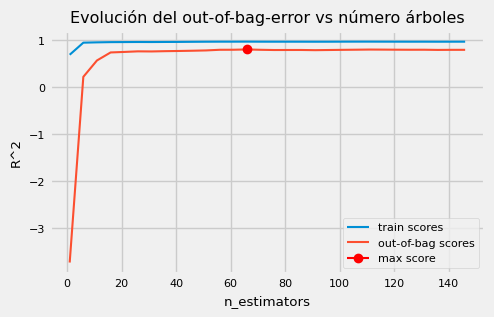

In [18]:
# Validación empleando el Out-of-Bag error
# ==============================================================================
warnings.filterwarnings('ignore')
train_scores = []
oob_scores   = []

# Valores evaluados
estimator_range = range(1, 150, 5)

# Bucle para entrenar un modelo con cada valor de n_estimators y extraer su error
# de entrenamiento y de Out-of-Bag.
for n_estimators in estimator_range:
    modelo = RandomForestRegressor(
                n_estimators = n_estimators,
                criterion    = 'squared_error',
                max_depth    = None,
                max_features = 1,
                oob_score    = True,
                n_jobs       = -1,
                random_state = 123
             )
    modelo.fit(X_train, y_train)
    train_scores.append(modelo.score(X_train, y_train))
    oob_scores.append(modelo.oob_score_)
    
# Gráfico con la evolución de los errores
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(estimator_range, train_scores, label="train scores")
ax.plot(estimator_range, oob_scores, label="out-of-bag scores")
ax.plot(estimator_range[np.argmax(oob_scores)], max(oob_scores),
        marker='o', color = "red", label="max score")
ax.set_ylabel("R^2")
ax.set_xlabel("n_estimators")
ax.set_title("Evolución del out-of-bag-error vs número árboles")
plt.legend();
print(f"Valor óptimo de n_estimators: {estimator_range[np.argmax(oob_scores)]}")
warnings.filterwarnings('default')


### ¿Qué es el error de falta de bolsa?
El **error fuera de la bolsa** (OOB - Out Of Bag) es un concepto crucial en el ámbito de aprendizaje automático, en particular cuando se trabaja con métodos de conjunto como Bosques aleatorios.    
Sirve como una métrica de validación interna que permite a los profesionales estimar el rendimiento de un modelo sin la necesidad de un conjunto de datos de validación separado.    
El error OOB se deriva de la técnica de muestreo bootstrap, donde se crean múltiples subconjuntos de los datos de entrenamiento mediante muestreo con reemplazo. Cada árbol individual en el Bosque al azar se entrena en un subconjunto diferente, y las instancias que no están incluidas en la muestra de arranque para un árbol en particular se denominan instancias "fuera de la bolsa".

Valor óptimo de n_estimators: 96


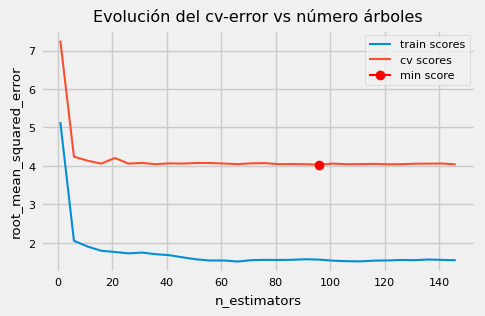

In [19]:
# Validación empleando k-cross-validation y neg_root_mean_squared_error
# ==============================================================================
train_scores = []
cv_scores    = []

# Valores evaluados
estimator_range = range(1, 150, 5)

# Bucle para entrenar un modelo con cada valor de n_estimators y extraer su error
# de entrenamiento y de k-cross-validation.
for n_estimators in estimator_range:
    
    modelo = RandomForestRegressor(
                n_estimators = n_estimators,
                criterion    = 'squared_error',
                max_depth    = None,
                max_features = 1,
                oob_score    = False,
                n_jobs       = -1,
                random_state = 123
             )
    
    # Error de entrenamiento
    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X=X_train)
    rmse = root_mean_squared_error(
            y_true  = y_train,
            y_pred  = predicciones,
           )
    train_scores.append(rmse)
    
    # Error de validación cruzada
    scores = cross_val_score(
                estimator = modelo,
                X         = X_train,
                y         = y_train,
                scoring   = 'neg_root_mean_squared_error',
                cv        = 5
             )
    # Se agregan los scores de cross_val_score() y se pasa a positivo
    cv_scores.append(-1*scores.mean())
    
# Gráfico con la evolución de los errores
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(estimator_range, train_scores, label="train scores")
ax.plot(estimator_range, cv_scores, label="cv scores")
ax.plot(estimator_range[np.argmin(cv_scores)], min(cv_scores),
        marker='o', color = "red", label="min score")
ax.set_ylabel("root_mean_squared_error")
ax.set_xlabel("n_estimators")
ax.set_title("Evolución del cv-error vs número árboles")
plt.legend();
print(f"Valor óptimo de n_estimators: {estimator_range[np.argmin(cv_scores)]}")


Si bien el valor óptimo de las métricas se alcanza con 66 y 96 árboles, las curvas indican que, a partir de 20 árboles, el error de validación del modelo se estabiliza.

### K-Cross Validation   

El método **K-Fold Cross-Validation** es un proceso iterativo. Consiste en dividir los datos de forma aleatoria en k grupos de aproximadamente el mismo tamaño, k-1 grupos se emplean para entrenar el modelo y uno de los grupos se emplea como validación. Este proceso se repite k veces utilizando un grupo distinto como validación en cada iteración. El proceso genera k estimaciones del error cuyo promedio se emplea como estimación final.

Dos ventajas del método K-Fold Cross-Validation frente al LOOCV:

- Requerimientos computacionales: el número de iteraciones necesarias viene determinado por el valor k escogido. Por lo general, se recomienda un k entre 5 y 10. LOOCV es un caso particular de K-Fold Cross-Validation en el que k = nº observaciones, si el data set es muy grande o el modelo muy complejo, se requiere muchas más iteraciones.

- Balance entre bias y varianza: la principal ventaja de K-fold CV es que consigue una estimación precisa del error de test gracias a un mejor balance entre bias y varianza.    

El método K-fold CV con valores de k= [5, 10] consigue un mejor balance final.

### Max features   

El valor de **máx_features** es uno de los hiperparámetros más importantes de random forest, ya que es el que permite controlar cuánto se decorrelacionan los árboles entre sí.

Valor óptimo de max_features: 4


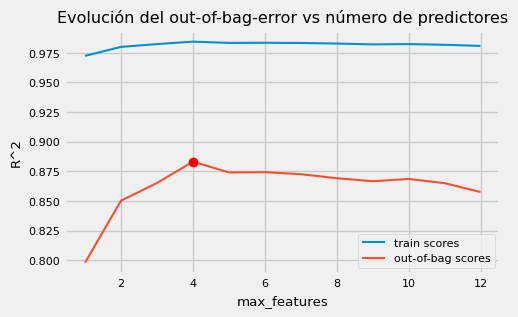

In [20]:
# Validación empleando el Out-of-Bag error
# ==============================================================================
train_scores = []
oob_scores   = []

# Valores evaluados
max_features_range = range(1, X_train.shape[1] + 1, 1)

# Bucle para entrenar un modelo con cada valor de max_features y extraer su error
# de entrenamiento y de Out-of-Bag.
for max_features in max_features_range:
    modelo = RandomForestRegressor(
                n_estimators = 100,
                criterion    = 'squared_error',
                max_depth    = None,
                max_features = max_features,
                oob_score    = True,
                n_jobs       = -1,
                random_state = 123
             )
    modelo.fit(X_train, y_train)
    train_scores.append(modelo.score(X_train, y_train))
    oob_scores.append(modelo.oob_score_)
    
# Gráfico con la evolución de los errores
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(max_features_range, train_scores, label="train scores")
ax.plot(max_features_range, oob_scores, label="out-of-bag scores")
ax.plot(max_features_range[np.argmax(oob_scores)], max(oob_scores),
        marker='o', color = "red")
ax.set_ylabel("R^2")
ax.set_xlabel("max_features")
ax.set_title("Evolución del out-of-bag-error vs número de predictores")
plt.legend();
print(f"Valor óptimo de max_features: {max_features_range[np.argmax(oob_scores)]}")


Valor óptimo de max_features: 6


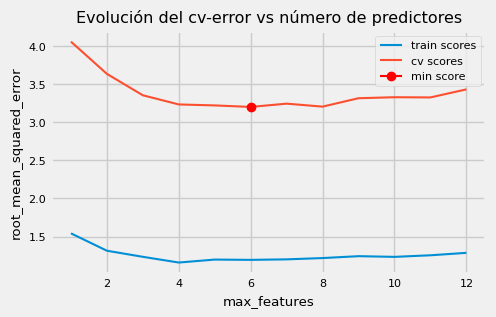

In [21]:
# Validación empleando k-cross-validation y neg_root_mean_squared_error
# ==============================================================================
train_scores = []
cv_scores    = []

# Valores evaluados
max_features_range = range(1, X_train.shape[1] + 1, 1)

# Bucle para entrenar un modelo con cada valor de max_features y extraer su error
# de entrenamiento y de k-cross-validation.
for max_features in max_features_range:
    
    modelo = RandomForestRegressor(
                n_estimators = 100,
                criterion    = 'squared_error',
                max_depth    = None,
                max_features = max_features,
                oob_score    = True,
                n_jobs       = -1,
                random_state = 123
             )
    
    # Error de train
    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X = X_train)
    rmse = root_mean_squared_error(
            y_true  = y_train,
            y_pred  = predicciones,
           )
    train_scores.append(rmse)
    
    # Error de validación cruzada
    scores = cross_val_score(
                estimator = modelo,
                X         = X_train,
                y         = y_train,
                scoring   = 'neg_root_mean_squared_error',
                cv        = 5
             )
    # Se agregan los scores de cross_val_score() y se pasa a positivo
    cv_scores.append(-1*scores.mean())
    
# Gráfico con la evolución de los errores
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(max_features_range, train_scores, label="train scores")
ax.plot(max_features_range, cv_scores, label="cv scores")
ax.plot(max_features_range[np.argmin(cv_scores)], min(cv_scores),
        marker='o', color = "red", label="min score")
ax.set_ylabel("root_mean_squared_error")
ax.set_xlabel("max_features")
ax.set_title("Evolución del cv-error vs número de predictores")
plt.legend();
print(f"Valor óptimo de max_features: {max_features_range[np.argmin(cv_scores)]}")
